In [31]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score


In [2]:
DATA_PATH = "/kaggle/input/nlpdataset/final_financial_causality_dataset.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

df.head()


,date,ticker,title,clean_text,return_t1,return_t5,volatility_5,causal_label
1591,2016-06-03,AA,Copyright board ruffles AA by rejecting logo c...,"Even after a go-around, American Airlines coul...",0.020374,0.001092,0.014083,1
1586,2018-02-15,AA,Citigroup Announces Redemption of Series AA Pr...,NEW YORK--(BUSINESS WIRE)-- Citigroup Inc. is ...,-0.019988,0.034585,0.017987,1
3460,2018-02-21,AA,AA's breakdown lands hedge funds $22 million p...,"February 21, 2018 / 12:00 PM / Updated 28 minu...",-0.010812,0.005279,0.018976,1
4883,2018-02-21,AA,"AA shares crash after dividend cut, profit for...","February 21, 2018 / 9:07 AM / Updated 24 minut...",-0.010812,0.005279,0.018976,1
5365,2018-02-21,AA,UPDATE 1-Britain's AA shares crash after divid...,"February 21, 2018 / 9:05 AM / Updated an hour ...",-0.010812,0.005279,0.018976,1


**CREATE FUTURE RETURNS (LABEL SHIFTING)**

In [4]:
df["future_return_1"] = (
    df.groupby("ticker")["return_t1"].shift(-1)
)

df["future_volatility_5"] = (
    df.groupby("ticker")["volatility_5"].shift(-1)
)


**CREATE NEW LABEL (LEAKAGE-FREE)**

In [5]:
return_thresh = df["future_return_1"].abs().quantile(0.75)
vol_thresh = df["future_volatility_5"].quantile(0.75)

df["causal_label_shifted"] = (
    (df["future_return_1"].abs() > return_thresh) |
    (df["future_volatility_5"] > vol_thresh)
).astype(int)


**DROP INVALID ROWS**

In [6]:
df = df.dropna(subset=[
    "return_t1",
    "return_t5",
    "volatility_5",
    "future_return_1",
    "future_volatility_5"
])


**BASIC SANITY CHECK**

In [7]:
print("Label distribution:")
print(df["causal_label_shifted"].value_counts(normalize=True))


Label distribution:
causal_label_shifted
0    0.636293
1    0.363707
Name: proportion, dtype: float64


**TIME-AWARE TRAIN / TEST SPLIT**

In [8]:
split_date = df["date"].quantile(0.8)

train_df = df[df["date"] <= split_date]
test_df  = df[df["date"] > split_date]

print("Train:", len(train_df), "Test:", len(test_df))


Train: 28888 Test: 7108


**DEFINE FEATURES & LABEL**

In [10]:
X_train = train_df[
    ["clean_text", "return_t1", "return_t5", "volatility_5"]
]
X_test = test_df[
    ["clean_text", "return_t1", "return_t5", "volatility_5"]
]

y_train = train_df["causal_label_shifted"]
y_test  = test_df["causal_label_shifted"]


**MULTIMODAL PIPELINE (TEXT + NUM)**

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=20000,
            ngram_range=(1,2),
            stop_words="english"
        ), "clean_text"),
        
        ("num", StandardScaler(),
         ["return_t1", "return_t5", "volatility_5"])
    ]
)


**MULTIMODAL LR**

In [12]:
model_mm_lr = Pipeline([
    ("features", preprocessor),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model_mm_lr.fit(X_train, y_train)

y_pred = model_mm_lr.predict(X_test)

print("MULTIMODAL LR")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


MULTIMODAL LR
Accuracy : 0.8579065841305571
Precision: 0.7831768068599428
Recall   : 0.8001668752607426
F1 Score : 0.7915806851011143


**MULTIMODAL SVM**

In [13]:
model_mm_svm = Pipeline([
    ("features", preprocessor),
    ("clf", LinearSVC(class_weight="balanced"))
])

model_mm_svm.fit(X_train, y_train)

y_pred = model_mm_svm.predict(X_test)

print("MULTIMODAL SVM F1:", f1_score(y_test, y_pred))


MULTIMODAL SVM F1: 0.7117194183062446


**TEXT-ONLY BASELINE (SHIFTED LABEL)**

In [14]:
model_text_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model_text_lr.fit(
    train_df["clean_text"],
    y_train
)

y_pred = model_text_lr.predict(test_df["clean_text"])

print("TEXT-ONLY LR F1:", f1_score(y_test, y_pred))


TEXT-ONLY LR F1: 0.32641660015961693


**Comparison Table**

In [15]:
results = []

def eval_model(name, y_pred):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

eval_model("Text LR", model_text_lr.predict(test_df["clean_text"]))
eval_model("Multimodal LR", model_mm_lr.predict(X_test))
eval_model("Multimodal SVM", model_mm_svm.predict(X_test))

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1
0,Text LR,0.525042,0.312811,0.341260,0.326417
1,Multimodal LR,0.857907,0.783177,0.800167,0.791581
2,Multimodal SVM,0.810355,0.730145,0.694201,0.711719


**Text-only Linear SVM**

In [18]:
model_text_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

model_text_svm.fit(train_df["clean_text"], y_train)

y_pred = model_text_svm.predict(test_df["clean_text"])

print("TEXT-ONLY SVM F1:", f1_score(y_test, y_pred))


TEXT-ONLY SVM F1: 0.3846441947565543


**Non-Linear Multimodal Model (Random Forest)**

In [19]:
from sklearn.ensemble import RandomForestClassifier

X_train_rf = preprocessor.fit_transform(X_train)
X_test_rf  = preprocessor.transform(X_test)

model_mm_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_mm_rf.fit(X_train_rf, y_train)

y_pred = model_mm_rf.predict(X_test_rf)

print("MULTIMODAL RF F1:", f1_score(y_test, y_pred))


MULTIMODAL RF F1: 0.5940938042848871


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [22]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [23]:
y_pred_text_lr = model_text_lr.predict(test_df["clean_text"])


**Confusion Matrix — Text-Only Logistic Regression**

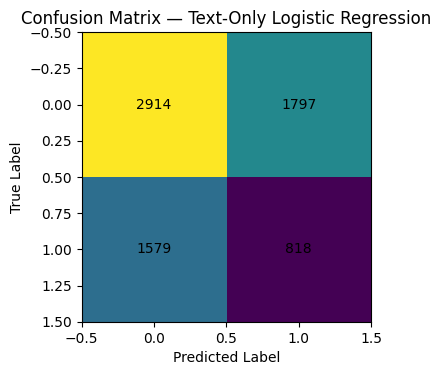

In [24]:
plot_confusion_matrix(
    y_test,
    y_pred_text_lr,
    "Confusion Matrix — Text-Only Logistic Regression"
)


In [25]:
f1_lr = f1_score(y_test, model_mm_lr.predict(X_test))
f1_svm = f1_score(y_test, model_mm_svm.predict(X_test))

print("Multimodal LR F1 :", f1_lr)
print("Multimodal SVM F1:", f1_svm)


Multimodal LR F1 : 0.7915806851011143
Multimodal SVM F1: 0.7117194183062446


**Confusion Matrix — Multimodal Logistic Regression**


In [26]:
y_pred_mm = model_mm_lr.predict(X_test)
title = "Confusion Matrix — Multimodal Logistic Regression"


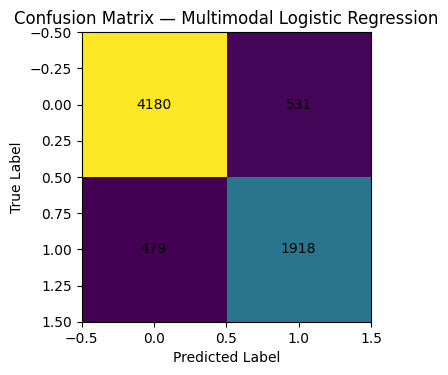

In [27]:
plot_confusion_matrix(
    y_test,
    y_pred_mm,
    title
)


**COMPARISON TABLE**

In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_results = []

def add_result(model_name, y_true, y_pred):
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    })

# 1️⃣ Text-only Logistic Regression
add_result(
    "Text-only Logistic Regression",
    y_test,
    model_text_lr.predict(test_df["clean_text"])
)

# 2️⃣ Multimodal Logistic Regression
add_result(
    "Multimodal Logistic Regression",
    y_test,
    model_mm_lr.predict(X_test)
)

# 3️⃣ Multimodal Linear SVM
add_result(
    "Multimodal Linear SVM",
    y_test,
    model_mm_svm.predict(X_test)
)

comparison_df = pd.DataFrame(comparison_results)
comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,Text-only Logistic Regression,0.525042,0.312811,0.341260,0.326417
1,Multimodal Logistic Regression,0.857907,0.783177,0.800167,0.791581
2,Multimodal Linear SVM,0.810355,0.730145,0.694201,0.711719


In [29]:
comparison_df.sort_values("F1-score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-score
1,Multimodal Logistic Regression,0.857907,0.783177,0.800167,0.791581
2,Multimodal Linear SVM,0.810355,0.730145,0.694201,0.711719
0,Text-only Logistic Regression,0.525042,0.312811,0.341260,0.326417


**Define Text-Only Models**

In [33]:
# Text-only Logistic Regression
model_text_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Text-only Linear SVM
model_text_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

# Text-only Naive Bayes
model_text_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        stop_words="english"
    )),
    ("clf", MultinomialNB())
])


**Train Models (TEXT ONLY)**

In [34]:
X_train_text = train_df["clean_text"]
X_test_text  = test_df["clean_text"]

model_text_lr.fit(X_train_text, y_train)
model_text_svm.fit(X_train_text, y_train)
model_text_nb.fit(X_train_text, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, stop_words='english')),
                ('clf', MultinomialNB())])

**Create Table  (Accuracy + F1)**

In [35]:
table1_results = []

def add_result(name, model):
    y_pred = model.predict(X_test_text)
    table1_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

add_result("TF-IDF + Logistic Regression", model_text_lr)
add_result("TF-IDF + Linear SVM", model_text_svm)
add_result("TF-IDF + Naive Bayes", model_text_nb)

table1_df = pd.DataFrame(table1_results)
table1_df


,Model,Accuracy,F1
0,TF-IDF + Logistic Regression,0.525042,0.326417
1,TF-IDF + Linear SVM,0.537704,0.384644
2,TF-IDF + Naive Bayes,0.394626,0.426954


**ROC CURVE — TEXT-ONLY LOGISTIC REGRESSION**

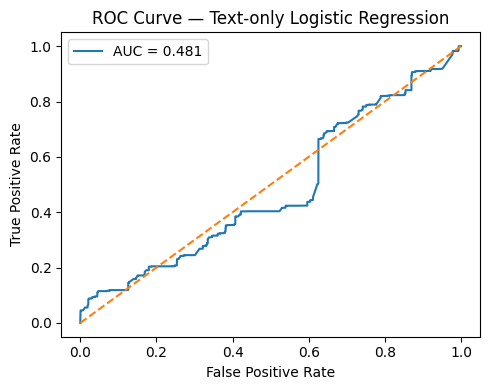

In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_prob_text_lr = model_text_lr.predict_proba(X_test_text)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_text_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Text-only Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


**ROC CURVE — MULTIMODAL LOGISTIC REGRESSION**

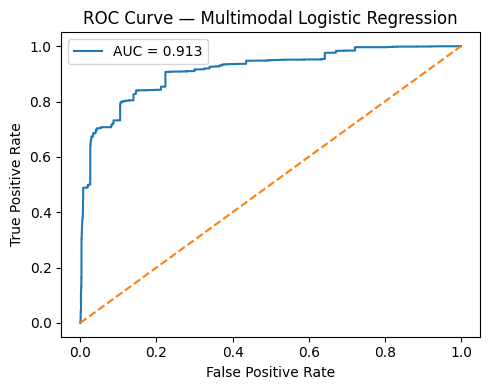

In [40]:
y_prob_mm_lr = model_mm_lr.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_mm_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Multimodal Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


**MODEL COMPARISON — ACCURACY PLOT**

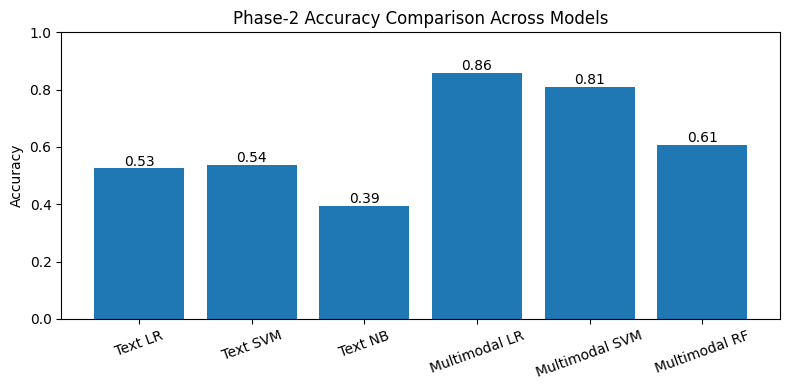

In [41]:
models = [
    "Text LR",
    "Text SVM",
    "Text NB",
    "Multimodal LR",
    "Multimodal SVM",
    "Multimodal RF"
]

accuracies = [
    accuracy_score(y_test, model_text_lr.predict(X_test_text)),
    accuracy_score(y_test, model_text_svm.predict(X_test_text)),
    accuracy_score(y_test, model_text_nb.predict(X_test_text)),
    accuracy_score(y_test, model_mm_lr.predict(X_test)),
    accuracy_score(y_test, model_mm_svm.predict(X_test)),
    accuracy_score(y_test, model_mm_rf.predict(X_test_rf))
]

plt.figure(figsize=(8,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Phase-2 Accuracy Comparison Across Models")
plt.ylim(0,1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
